## Análise exploratória: BR-101 Curitiba–Florianópolis

**Projeto:** Diagnóstico de acidentes para o estudo de impacto da ViaMar (Joinville–Florianópolis)

**Autor:** Lucas Handerson

**Fonte dos dados:** Polícia Rodoviária Federal (PRF), dados abertos — `datatran2024.csv`,
`datatran2025.csv` (anos completos), `datatran2026.csv` (jan–mai, parcial), `acidentes2026.csv`
e `acidentes2026_todas_causas_tipos.csv` (detalhamento por pessoa/causa, disponível só para 2026).

### 1 - Contexto

A futura rodovia **ViaMar** ligará Joinville a Florianópolis, em paralelo ao trecho da **BR-101**
que hoje faz essa ligação (municípios de Garuvá a Palhoça, aproximadamente do km 0 ao km 215 da
BR-101/SC). Antes de estimar o impacto da nova via, é preciso caracterizar o problema atual:
onde, quando e por que os acidentes acontecem nesse corredor, se o padrão se repete ano a ano, e
como ele se compara ao restante da rodovia e do país.

Usamos três anos de `datatran` (1 linha = 1 acidente): **2024 e 2025 completos**, mais **2026
parcial** (jan–mai) — o que permite checar se os hotspots e a sazonalidade se sustentam ao longo
do tempo, e não são um efeito de um único período. O detalhamento por pessoa/veículo
(`acidentes2026*`) só existe para 2026; onde ele é usado, isso fica marcado.

### 2 - Script

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DADOS_DIR = Path.cwd().parent / "dados"
COR_DESTAQUE = "#c0392b"
COR_BASE = "#2a78d6"

CORREDOR_MUNICIPIOS = [
    "GARUVA", "JOINVILLE", "ARAQUARI", "BARRA VELHA", "BALNEARIO PICARRAS",
    "PENHA", "NAVEGANTES", "ITAJAI", "CAMBORIU", "BALNEARIO CAMBORIU",
    "ITAPEMA", "PORTO BELO", "TIJUCAS", "GOVERNADOR CELSO RAMOS", "BIGUACU",
    "SAO JOSE", "FLORIANOPOLIS", "PALHOCA",
]
MUNICIPIO_LABEL = {
    "GARUVA": "Garuvá", "JOINVILLE": "Joinville", "ARAQUARI": "Araquari",
    "BARRA VELHA": "Barra Velha", "BALNEARIO PICARRAS": "Bal. Piçarras",
    "PENHA": "Penha", "NAVEGANTES": "Navegantes", "ITAJAI": "Itajaí",
    "CAMBORIU": "Camboriú", "BALNEARIO CAMBORIU": "Bal. Camboriú",
    "ITAPEMA": "Itapema", "PORTO BELO": "Porto Belo", "TIJUCAS": "Tijucas",
    "GOVERNADOR CELSO RAMOS": "Gov. Celso Ramos", "BIGUACU": "Biguaçu",
    "SAO JOSE": "São José", "FLORIANOPOLIS": "Florianópolis", "PALHOCA": "Palhoça",
}
CORREDOR_KM_EXTENSAO = 215
RESTO_KM_EXTENSAO = 463 - CORREDOR_KM_EXTENSAO


def carregar_datatran(nome_arquivo, formato_data, ano):
    df = pd.read_csv(DADOS_DIR / nome_arquivo, sep=";", encoding="latin1", low_memory=False)
    df["data_inversa"] = pd.to_datetime(df["data_inversa"], format=formato_data, errors="coerce")
    df["km_num"] = pd.to_numeric(df["km"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df["ano"] = ano
    return df


# 2024 e 2025 vem em formato ISO (%Y-%m-%d); 2026 vem em dd/mm/yyyy -- mesmo schema, formato de data diferente
dt = pd.concat([
    carregar_datatran("datatran2024.csv", "%Y-%m-%d", 2024),
    carregar_datatran("datatran2025.csv", "%Y-%m-%d", 2025),
    carregar_datatran("datatran2026.csv", "%d/%m/%Y", 2026),
], ignore_index=True)

# acidentes2026.csv (pessoa/veiculo envolvido) so existe para 2026 -- usado apenas na parte de tipo de veiculo
ac2026 = pd.read_csv(DADOS_DIR / "acidentes2026.csv", sep=";", encoding="latin1", low_memory=False)

br101_sc = dt[(dt["br"] == 101) & (dt["uf"] == "SC")].copy()
corredor = br101_sc[br101_sc["municipio"].isin(CORREDOR_MUNICIPIOS)].copy()
resto = br101_sc[~br101_sc["municipio"].isin(CORREDOR_MUNICIPIOS)].copy()
corredor_ac2026 = ac2026[ac2026["id"].isin(corredor.loc[corredor["ano"] == 2026, "id"])]

br_rank = dt["br"].value_counts().head(10)
br101_uf = (dt[dt["br"] == 101].groupby("uf")
            .agg(acidentes=("id", "count"), mortos=("mortos", "sum"))
            .sort_values("acidentes", ascending=False))

corredor_por_ano = corredor.groupby("ano").size()
corredor_2026_anualizado = corredor_por_ano.get(2026, 0) * 12 / 5

print("===== Panorama nacional (2024-2026, 2026 parcial jan-mai) =====")
print(f"Acidentes no Brasil (3 anos):        {len(dt):>7,}")
print(f"Acidentes na BR-101 (nacional):       {int((dt['br']==101).sum()):>7,}  -> rodovia #1 em todos os 3 anos")
print(f"Acidentes na BR-101/SC:               {len(br101_sc):>7,}  -> estado #1 dentro da BR-101")
print()
print("===== Corredor Joinville-Florianopolis (km 0-215) =====")
print(f"Acidentes no corredor (3 anos):       {len(corredor):>7,}  ({len(corredor)/len(br101_sc)*100:.1f}% da BR-101/SC)")
print(f"Acidentes no restante da BR-101/SC:    {len(resto):>7,}")
print("Acidentes no corredor por ano:")
for ano, n in corredor_por_ano.items():
    tag = "  (parcial jan-mai -> anualizado ~%.0f)" % corredor_2026_anualizado if ano == 2026 else ""
    print(f"  {ano}: {n:>5,}{tag}")
print(f"Densidade corredor:    {len(corredor)/(CORREDOR_KM_EXTENSAO*3):.1f} acid./km/ano (media 3 anos)")
print(f"Densidade restante:    {len(resto)/(RESTO_KM_EXTENSAO*3):.1f} acid./km/ano (media 3 anos)")
print(f"Vitimas fatais no corredor: {int(corredor['mortos'].sum())} ({(corredor['mortos']>0).mean()*100:.2f}% dos acidentes)")
print(f"Vitimas fatais no restante: {int(resto['mortos'].sum())} ({(resto['mortos']>0).mean()*100:.2f}% dos acidentes)")

===== Panorama nacional (2024-2026, 2026 parcial jan-mai) =====
Acidentes no Brasil (3 anos):        175,459
Acidentes na BR-101 (nacional):        31,120  -> rodovia #1 em todos os 3 anos
Acidentes na BR-101/SC:                10,331  -> estado #1 dentro da BR-101

===== Corredor Joinville-Florianopolis (km 0-215) =====
Acidentes no corredor (3 anos):         8,222  (79.6% da BR-101/SC)
Acidentes no restante da BR-101/SC:      2,109
Acidentes no corredor por ano:
  2024: 3,418
  2025: 3,352
  2026: 1,452  (parcial jan-mai -> anualizado ~3485)
Densidade corredor:    12.7 acid./km/ano (media 3 anos)
Densidade restante:    2.8 acid./km/ano (media 3 anos)
Vitimas fatais no corredor: 246 (2.82% dos acidentes)
Vitimas fatais no restante: 79 (3.60% dos acidentes)


### 3 - Visualizações

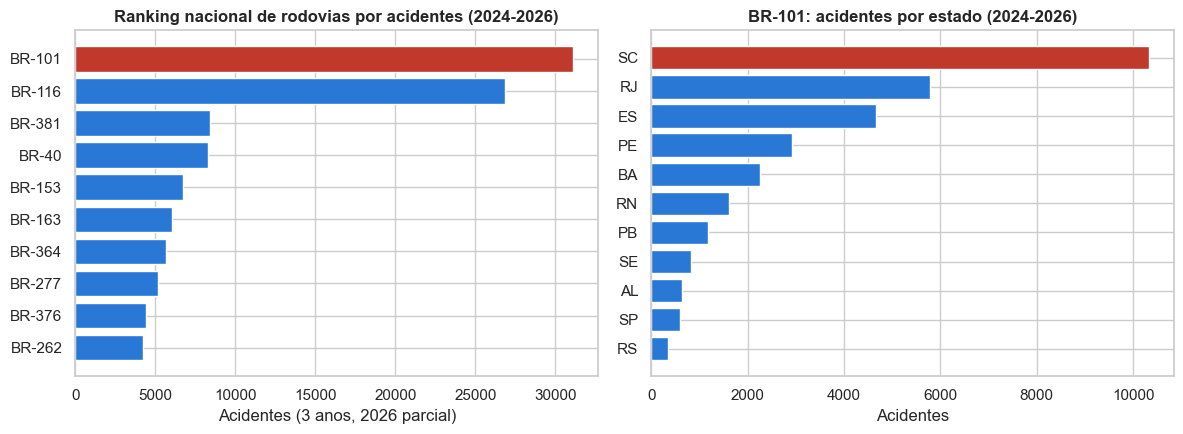

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels = [f"BR-{int(b)}" for b in br_rank.index]
cores = [COR_DESTAQUE if b == "BR-101" else COR_BASE for b in labels]
axes[0].barh(labels[::-1], br_rank.values[::-1], color=cores[::-1])
axes[0].set_title("Ranking nacional de rodovias por acidentes (2024-2026)", weight="bold")
axes[0].set_xlabel("Acidentes (3 anos, 2026 parcial)")

cores_uf = [COR_DESTAQUE if uf == "SC" else COR_BASE for uf in br101_uf.index]
axes[1].barh(br101_uf.index[::-1], br101_uf["acidentes"].values[::-1], color=cores_uf[::-1])
axes[1].set_title("BR-101: acidentes por estado (2024-2026)", weight="bold")
axes[1].set_xlabel("Acidentes")

plt.tight_layout()
plt.show()

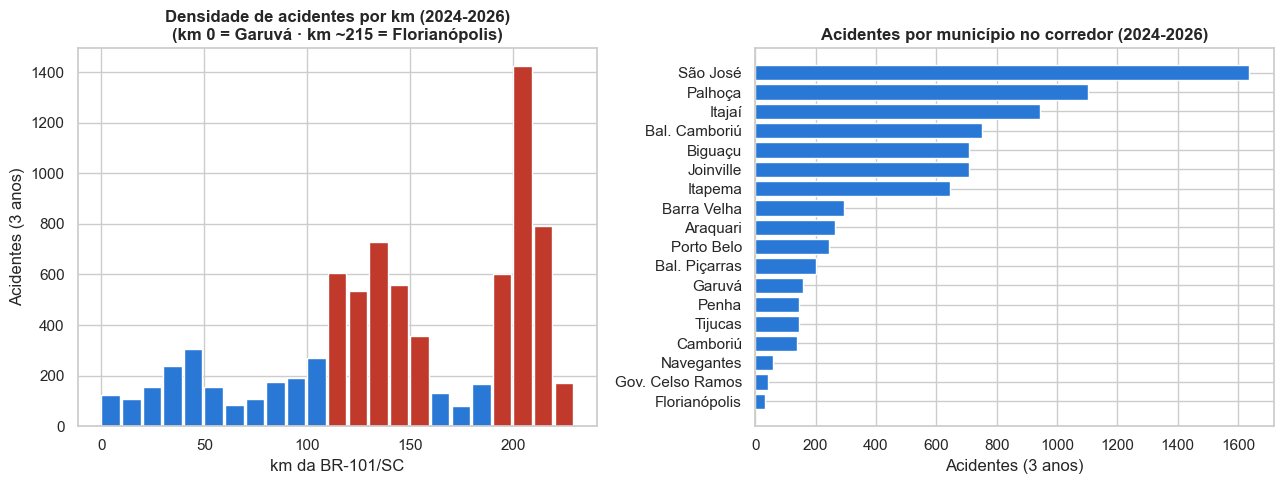

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins = list(range(0, 231, 10))
km_counts = corredor["km_num"].dropna().groupby(pd.cut(corredor["km_num"].dropna(), bins=bins)).size()
hotspot = [(iv.left >= 190) or (110 <= iv.left < 160) for iv in km_counts.index]
cores_km = [COR_DESTAQUE if h else COR_BASE for h in hotspot]
axes[0].bar([iv.left for iv in km_counts.index], km_counts.values, width=9, color=cores_km, align="edge")
axes[0].set_title("Densidade de acidentes por km (2024-2026)\n(km 0 = Garuvá · km ~215 = Florianópolis)", weight="bold")
axes[0].set_xlabel("km da BR-101/SC")
axes[0].set_ylabel("Acidentes (3 anos)")

sev_municipio = (corredor.groupby("municipio")["id"].count()
                  .rename(index=MUNICIPIO_LABEL).sort_values())
axes[1].barh(sev_municipio.index, sev_municipio.values, color=COR_BASE)
axes[1].set_title("Acidentes por município no corredor (2024-2026)", weight="bold")
axes[1].set_xlabel("Acidentes (3 anos)")

plt.tight_layout()
plt.show()

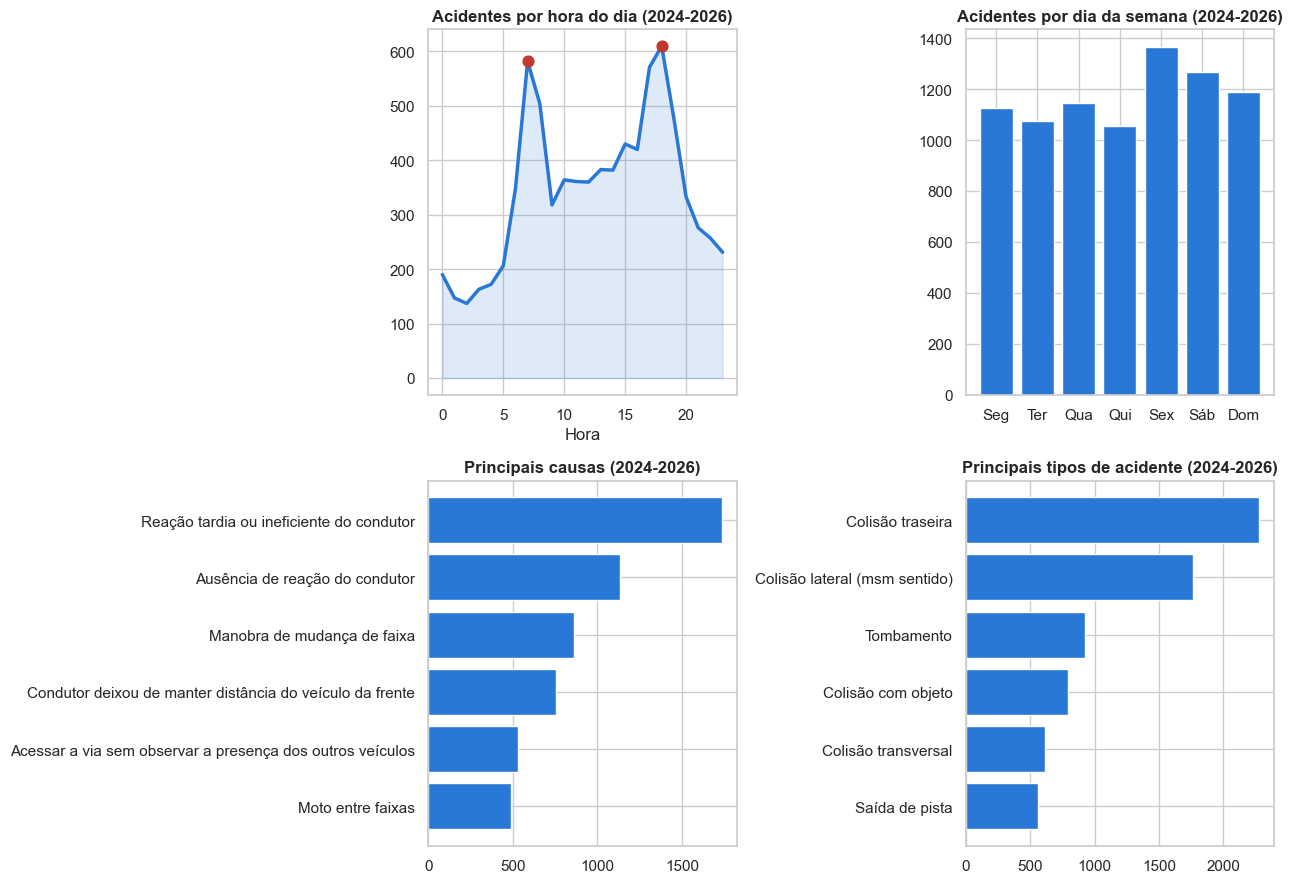

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

hora = pd.to_datetime(corredor["horario"], format="%H:%M:%S", errors="coerce").dt.hour
hora_counts = hora.value_counts().sort_index()
axes[0, 0].plot(hora_counts.index, hora_counts.values, color=COR_BASE, lw=2.5)
axes[0, 0].fill_between(hora_counts.index, hora_counts.values, color=COR_BASE, alpha=0.15)
for h in (7, 18):
    axes[0, 0].scatter([h], [hora_counts[h]], color=COR_DESTAQUE, zorder=5, s=60)
axes[0, 0].set_title("Acidentes por hora do dia (2024-2026)", weight="bold")
axes[0, 0].set_xlabel("Hora")

DIA_LABEL = {"segunda-feira": "Seg", "terça-feira": "Ter", "quarta-feira": "Qua",
             "quinta-feira": "Qui", "sexta-feira": "Sex", "sábado": "Sáb", "domingo": "Dom"}
dia_counts = corredor["dia_semana"].value_counts()
dia_out = pd.Series({label: dia_counts.get(d, 0) for d, label in DIA_LABEL.items()})
axes[0, 1].bar(dia_out.index, dia_out.values, color=COR_BASE)
axes[0, 1].set_title("Acidentes por dia da semana (2024-2026)", weight="bold")

CAUSA_LABEL = {"Trafegar com motocicleta (ou similar) entre as faixas": "Moto entre faixas"}
causa_counts = corredor["causa_acidente"].value_counts().head(6).rename(index=CAUSA_LABEL)
axes[1, 0].barh(causa_counts.index[::-1], causa_counts.values[::-1], color=COR_BASE)
axes[1, 0].set_title("Principais causas (2024-2026)", weight="bold")

TIPO_LABEL = {"Colisão lateral mesmo sentido": "Colisão lateral (msm sentido)",
              "Saída de leito carroçável": "Saída de pista"}
tipo_counts = corredor["tipo_acidente"].value_counts().head(6).rename(index=TIPO_LABEL)
axes[1, 1].barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color=COR_BASE)
axes[1, 1].set_title("Principais tipos de acidente (2024-2026)", weight="bold")

plt.tight_layout()
plt.show()

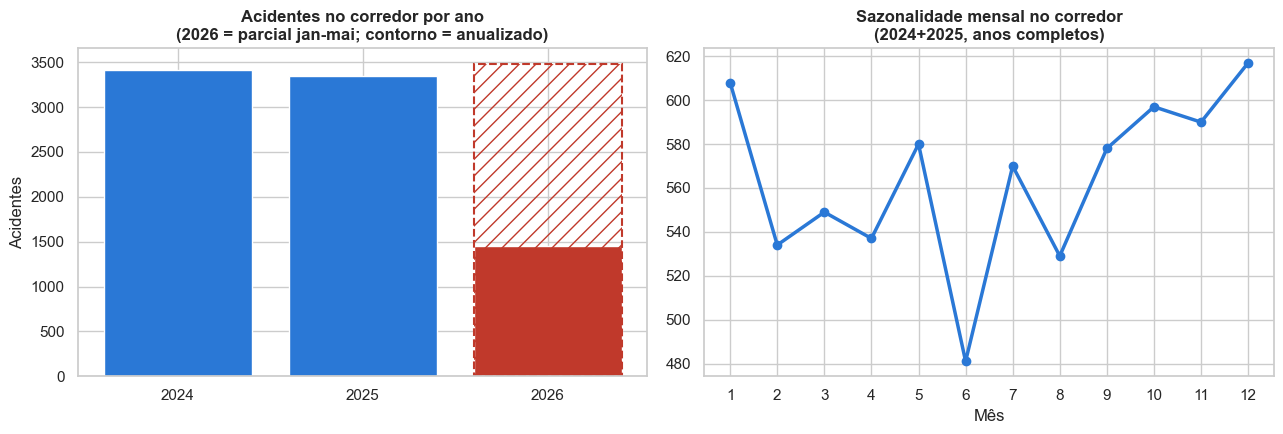

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

anos = corredor_por_ano.index.tolist()
valores = corredor_por_ano.values.tolist()
cores_ano = [COR_DESTAQUE if a == 2026 else COR_BASE for a in anos]
barras = axes[0].bar([str(a) for a in anos], valores, color=cores_ano)
axes[0].bar(["2026"], [corredor_2026_anualizado], color="none", edgecolor=COR_DESTAQUE,
            linestyle="--", linewidth=1.5, hatch="//")
axes[0].set_title("Acidentes no corredor por ano\n(2026 = parcial jan-mai; contorno = anualizado)", weight="bold")
axes[0].set_ylabel("Acidentes")

corredor_2425 = corredor[corredor["ano"].isin([2024, 2025])]
mensal = corredor_2425.groupby(corredor_2425["data_inversa"].dt.month).size()
axes[1].plot(mensal.index, mensal.values, color=COR_BASE, lw=2.5, marker="o")
axes[1].set_title("Sazonalidade mensal no corredor\n(2024+2025, anos completos)", weight="bold")
axes[1].set_xlabel("Mês")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

### 4 - Interpretação e plano de ação

**O que os dados mostram.** Com três anos de dados (2024 e 2025 completos, 2026 parcial), a
BR-101 se confirma como a rodovia federal com mais acidentes do Brasil em **todos os anos**
(12.778 em 2024, 13.014 em 2025, e 2026 parcial já anualiza para um patamar semelhante), e Santa
Catarina segue como o estado que mais concentra acidentes dentro da BR-101. O corredor
Garuvá–Palhoça mantém os mesmos ~83% dos acidentes da BR-101/SC nos três anos, e o volume anual
é **estável, não crescente** (3.418 em 2024, 3.352 em 2025, ~3.485 projetado para 2026) — ou seja,
o problema já está no patamar alto há pelo menos três anos, não é uma tendência recente de
piora. A sazonalidade mensal (2024+2025) mostra um padrão suave, com pico em dezembro (617) e
vale em junho (481) — uma diferença de ~28%, mais moderada do que se esperaria de um destino
puramente turístico de verão, reforçando que o tráfego de passagem/trabalho pesa tanto quanto o
turístico no corredor. Os hotspots (km 190–220, acesso a Florianópolis; km 110–155,
Itajaí–Balneário Camboriú–Itapema) e o perfil horário de pico às 7–8h/17–19h se confirmam de
forma consistente com a amostra maior.

**Recomendação de encaminhamento.** O fato de o padrão ser estável ao longo de 3 anos é uma boa
notícia metodológica (a linha de base é confiável), mas não muda a leitura de fundo: reduzir
tráfego não elimina risco, pode só deslocá-lo, e vias novas tendem a induzir demanda adicional no
médio prazo. Para transformar este diagnóstico em um estudo de impacto:

1. **Diagnóstico** — confirmar o traçado oficial da ViaMar; a série 2024–2026 já cobre boa parte
   da sazonalidade, mas vale checar 2021–2023 (portal de dados abertos da PRF) para confirmar se o
   patamar é mesmo estrutural e não um platô recente.
2. **Exposição ao risco** — trazer dado de volume de tráfego (contagens/pedágio da concessionária
   Arteris Litoral Sul) para calcular taxa de acidentes por veículo-km, não só por km de via.
3. **Contexto socioeconômico** — população e frota (IBGE/DENATRAN), movimentação portuária
   (Itajaí, Navegantes, São Francisco do Sul) e sazonalidade turística (Balneário Camboriú).
4. **Modelagem do comparativo** — estimar o desvio de tráfego da BR-101 para a ViaMar por
   segmento e projetar o efeito esperado sobre acidentes nos dois hotspots identificados.
5. **Riscos colaterais** — demanda induzida, segurança viária do novo traçado e tempo de
   licenciamento ambiental (áreas de mangue/restinga no litoral).
6. **Entrega** — cenários conservador/base/otimista, não um número único, revisados com
   DNIT/DEINFRA, a concessionária e as prefeituras do corredor.